<a href="https://colab.research.google.com/github/k98j/Research-Projects/blob/main/Geometric_Invariance_of_Visual_Representations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install -q transformers torchvision scikit-learn matplotlib seaborn

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from torchvision import datasets, transforms
from torchvision.transforms import functional as F

print(torch.cuda.is_available())

True


In [18]:
dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True
)

len(dataset)

10000

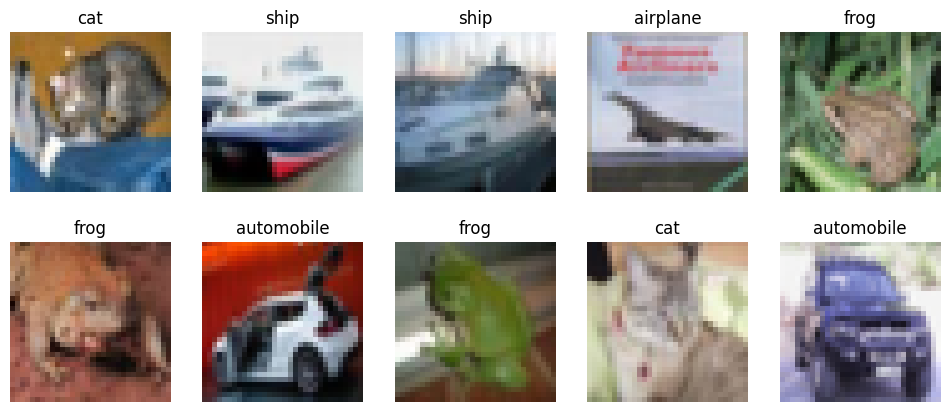

In [19]:
fig, axes = plt.subplots(2,5, figsize=(12,5))

for i, ax in enumerate(axes.flat):
    img, label = dataset[i]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(dataset.classes[label])

In [20]:
def make_variants(img):

    return {
        "original": img,
        "rotation": F.rotate(img, 45),
        "crop": F.center_crop(img, 24).resize((32,32)),
        "flip": F.hflip(img),
        "scale": F.resize(img, (48,48))
    }

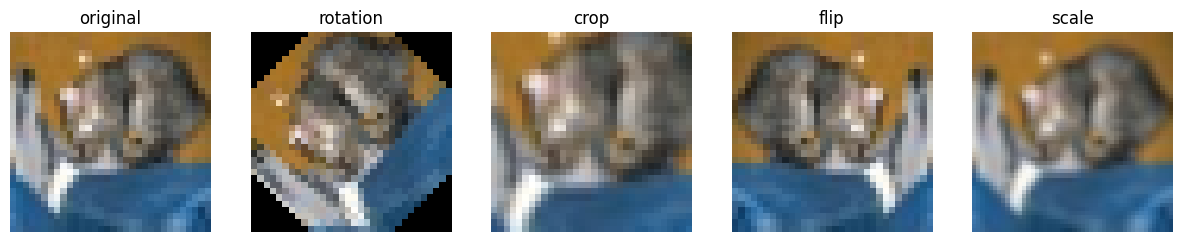

In [21]:
img, label = dataset[0]

variants = make_variants(img)

fig, axes = plt.subplots(1,5, figsize=(15,3))

for ax, (name, image) in zip(axes, variants.items()):
    ax.imshow(image)
    ax.set_title(name)
    ax.axis("off")

In [22]:
from transformers import AutoImageProcessor, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(
    "facebook/dinov2-base"
)

dino = AutoModel.from_pretrained(
    "facebook/dinov2-base"
).to(device)

dino.eval()

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-06,

In [23]:
def dino_embedding(img):

    inputs = processor(
        images=img,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k,v in inputs.items()
    }

    with torch.no_grad():

        outputs = dino(**inputs)

    z = outputs.last_hidden_state[:,0,:]

    return z.cpu().numpy()[0]

In [24]:
z = dino_embedding(dataset[0][0])

z.shape

(768,)

In [25]:
from sklearn.metrics.pairwise import cosine_similarity

def similarity(z1, z2):
    return cosine_similarity(
        z1.reshape(1,-1),
        z2.reshape(1,-1)
    )[0,0]

In [26]:
results = {
    "rotation": [],
    "crop": [],
    "flip": [],
    "scale": []
}

for i in range(100):

    img, label = dataset[i]

    variants = make_variants(img)

    original_embedding = dino_embedding(
        variants["original"]
    )

    for transformation in results:

        transformed_embedding = dino_embedding(
            variants[transformation]
        )

        sim = similarity(
            original_embedding,
            transformed_embedding
        )

        results[transformation].append(sim)

In [27]:
for transformation, values in results.items():

    print(
        transformation,
        np.mean(values),
        np.std(values)
    )

rotation 0.31494007 0.1610556
crop 0.8059889 0.112454854
flip 0.9666032 0.02177116
scale 0.955061 0.034219116


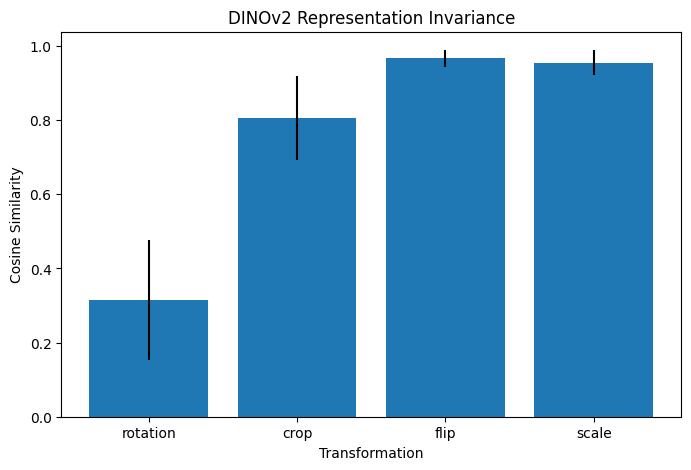

In [28]:
means = [
    np.mean(results[x])
    for x in results
]

stds = [
    np.std(results[x])
    for x in results
]

plt.figure(figsize=(8,5))

plt.bar(
    list(results.keys()),
    means,
    yerr=stds
)

plt.ylabel("Cosine Similarity")
plt.xlabel("Transformation")
plt.title("DINOv2 Representation Invariance")

plt.show()

In [29]:
negative_similarities = []

for i in range(100):

    img1, _ = dataset[i]
    img2, _ = dataset[(i+100) % 100]

    z1 = dino_embedding(img1)
    z2 = dino_embedding(img2)

    negative_similarities.append(
        similarity(z1,z2)
    )

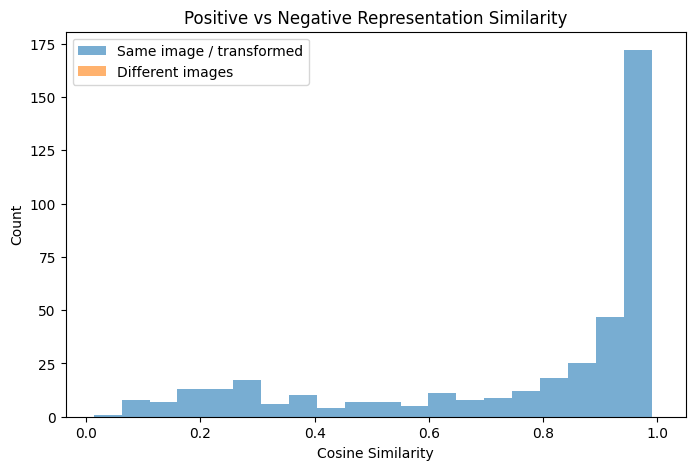

In [30]:
positive = []

for transformation in results:
    positive.extend(results[transformation])

plt.figure(figsize=(8,5))

plt.hist(
    positive,
    bins=20,
    alpha=0.6,
    label="Same image / transformed"
)

plt.hist(
    negative_similarities,
    bins=20,
    alpha=0.6,
    label="Different images"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.legend()

plt.title("Positive vs Negative Representation Similarity")

plt.show()